In [1]:
import sys
from pathlib import Path
from functools import reduce

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

project_root = Path().resolve().parents[0]
sys.path.append(str(project_root))
import src.fc_analysis as fca

In [2]:
K_dict = np.load('../data/processed/vmd_fc.pkl', allow_pickle=True)

In [4]:
K_list = []
IMF_list = []
fc_list = []
for K in K_dict.keys():
    for IMF in K_dict[K].keys():
        K_list.append(K)
        IMF_list.append(IMF+1)
        fc_list.append(K_dict[K][IMF])
df_fc = pd.DataFrame({'K':K_list, 'IMF':IMF_list, 'fc':fc_list})
print(df_fc.shape)
df_fc.head()

(209, 3)


,K,IMF,fc
0,2,1,0.000236
1,2,2,0.082889
2,3,1,0.000235
3,3,2,0.082875
4,3,3,0.164891


In [5]:
df_fc = reduce(
    lambda l, r:l.merge(r, on='K', how='outer'),
    [fca.find_fc_max(df_fc), fca.find_cfr_min_max(df_fc), fca.find_cfr_roc(df_fc), fca.find_cfr_K(df_fc), fca.find_fc_sd(df_fc)]
).sort_values(by='K', ascending=True)
print(df_fc.shape)
df_fc.head(20)

(19, 6)


,K,fc_max,CFR (max/min),CFR (RoC),CFR (K/(K-1)),fc_sd
0,2,0.082889,350.801156,NaN,NaN,0.058444
1,3,0.164891,700.731367,1.997517,1.989302,0.082328
2,4,0.370023,1573.557301,2.245593,2.244044,0.158625
3,5,0.414469,1765.200433,1.121790,1.120116,0.159210
4,6,0.415159,1770.212533,1.002839,1.001666,0.149234
5,7,0.416282,1788.376177,1.010261,1.002704,0.144785
6,8,0.457035,1965.095423,1.098815,1.097898,0.153232
7,9,0.457380,2204.594629,1.121877,1.000755,0.152850
8,10,0.459355,2215.173297,1.004798,1.004319,0.154929
9,11,0.459752,2227.238916,1.005447,1.000863,0.153645


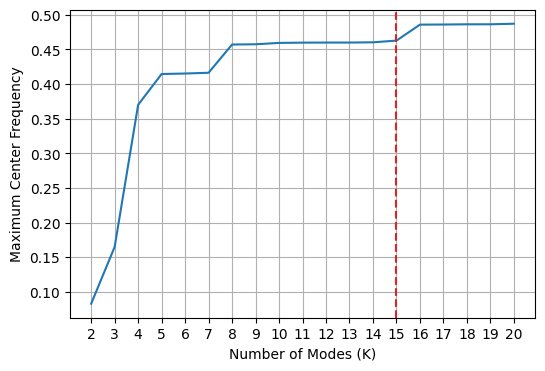

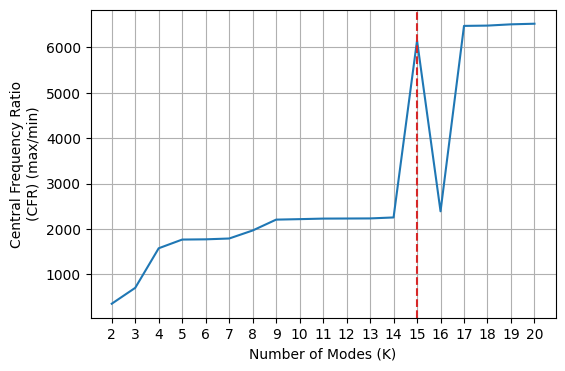

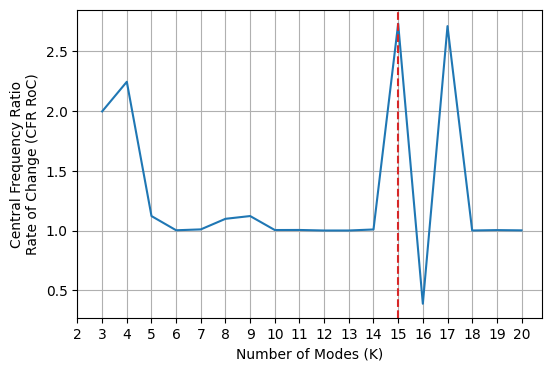

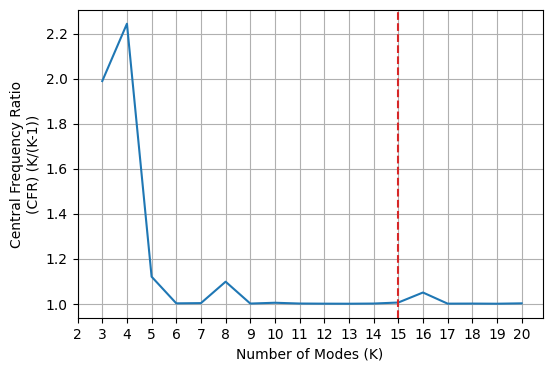

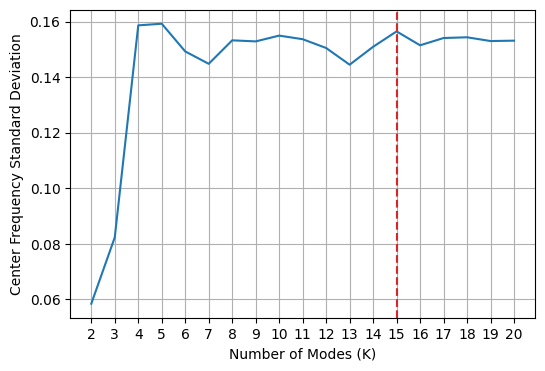

In [6]:
for col, lab in zip(['fc_max', 'CFR (max/min)', 'CFR (RoC)', 'CFR (K/(K-1))', 'fc_sd'], ['Maximum Center Frequency', 'Central Frequency Ratio\n(CFR) (max/min)', 'Central Frequency Ratio\nRate of Change (CFR RoC)', 'Central Frequency Ratio\n(CFR) (K/(K-1))', 'Center Frequency Standard Deviation']):
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.plot(df_fc['K'], df_fc[col], c='tab:blue')
    ax.set_ylabel(lab)
    ax.set_xlabel('Number of Modes (K)')
    ax.set_xticks([_ for _ in range(2, 21)])
    ax.grid()
    ax.axvline(15, color='tab:red', linestyle='--')
    plt.show()

In [12]:
corr_dict = np.load('../data/processed/vmd_corr.pkl', allow_pickle=True)
K_list = []
IMF_list = []
corr_list = []
for K in K_dict.keys():
    for IMF in K_dict[K].keys():
        K_list.append(K)
        IMF_list.append(IMF+1)
        corr_list.append(corr_dict[K][IMF])
df_corr = pd.DataFrame({'K':K_list, 'IMF':IMF_list, 'corr':corr_list})
print(df_corr.shape)
df_corr.head()

(209, 3)


,K,IMF,corr
0,2,1,0.950871
1,2,2,0.242793
2,3,1,0.950730
3,3,2,0.241748
4,3,3,0.083672


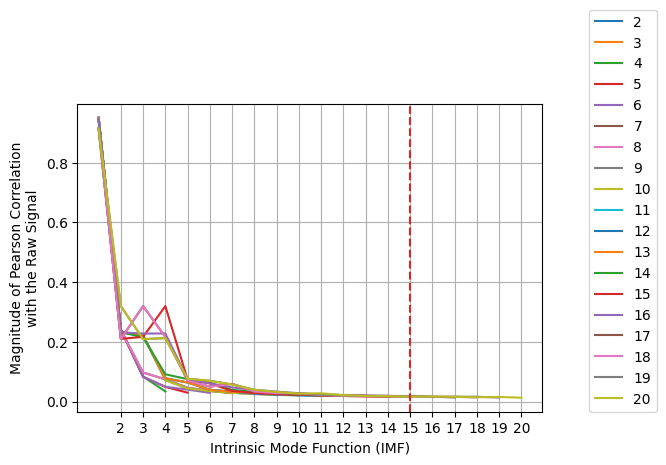

In [20]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.lineplot(data=df_corr, x='IMF', y='corr', hue='K', palette='tab10')
ax.set_ylabel('Magnitude of Pearson Correlation\nwith the Raw Signal')
ax.set_xlabel('Intrinsic Mode Function (IMF)')
ax.set_xticks([_ for _ in range(2, 21)])
ax.legend(loc=[1.1, 0])
ax.grid()
ax.axvline(15, color='tab:red', linestyle='--')
plt.show()